In [4]:
# ==============================
# IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8")

In [5]:
# ==============================
# LOAD DATA
# ==============================

file_path = "Asset creation.xlsx"
df = pd.read_excel(file_path)

# Clean column names
df.columns = df.columns.astype(str).str.strip()

df.head()

,Sl No,zone_cd,Zone,reg_cd,Region,Division,div_cd,2026-02,2026-01,2025-12,2025-11,2025-10,2025-09,Total,Monthly average
0,1,31,Kolkata,311,24-PARGANAS (SOUTH),BEHALA DIVN.,3112000,39,13,14,38,4,7,115,19
1,2,31,Kolkata,311,24-PARGANAS (SOUTH),BARUIPUR DIVN.,3113000,15,30,17,14,11,8,95,16
2,3,31,Kolkata,311,24-PARGANAS (SOUTH),GARIA DIVN.,3115000,38,40,31,7,16,29,161,27
3,4,31,Kolkata,311,24-PARGANAS (SOUTH),JOYNAGAR DIVISION,3116000,16,1,10,6,1,0,34,6
4,5,31,Kolkata,311,24-PARGANAS (SOUTH),DIAMOND HARBOUR DIVN.,3117000,5,2,2,3,0,5,17,3


In [6]:
print("Shape of data:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())

Shape of data: (79, 15)

Columns:
 Index(['Sl No', 'zone_cd', 'Zone', 'reg_cd', 'Region', 'Division', 'div_cd',
       '2026-02', '2026-01', '2025-12', '2025-11', '2025-10', '2025-09',
       'Total', 'Monthly average'],
      dtype='object')

Missing Values:
 Sl No              0
zone_cd            0
Zone               0
reg_cd             0
Region             0
Division           0
div_cd             0
2026-02            0
2026-01            0
2025-12            0
2025-11            0
2025-10            0
2025-09            0
Total              0
Monthly average    0
dtype: int64


In [7]:
# Adjust if column names differ slightly
month_cols = ["2025-09","2025-10","2025-11","2025-12","2026-01","2026-02"]

# Ensure numeric
df[month_cols] = df[month_cols].apply(pd.to_numeric, errors="coerce")

In [8]:
# If Total column does not exist, create it
if "Total" not in df.columns:
    df["Total"] = df[month_cols].sum(axis=1)

total_assets = df["Total"].sum()
print("Total Assets Created:", total_assets)

Total Assets Created: 12951


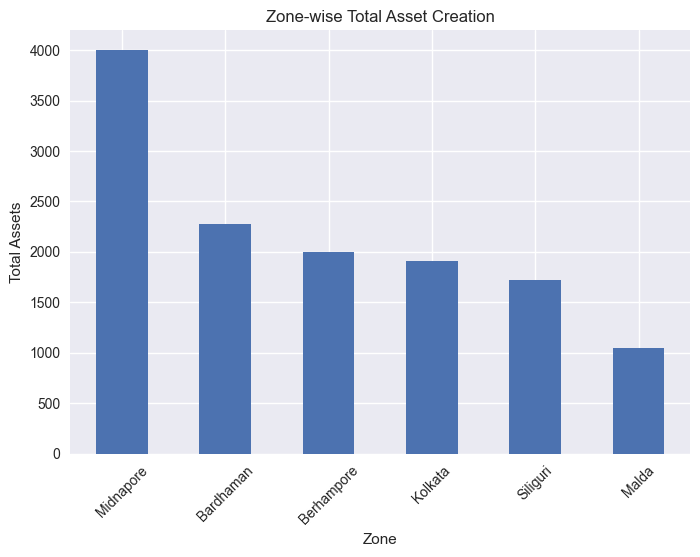

Zone
Midnapore     3996
Bardhaman     2280
Berhampore    1998
Kolkata       1914
Siliguri      1718
Malda         1045
Name: Total, dtype: int64

In [9]:
zone_summary = df.groupby("Zone")["Total"].sum().sort_values(ascending=False)

plt.figure()
zone_summary.plot(kind="bar")
plt.title("Zone-wise Total Asset Creation")
plt.xlabel("Zone")
plt.ylabel("Total Assets")
plt.xticks(rotation=45)
plt.show()

zone_summary

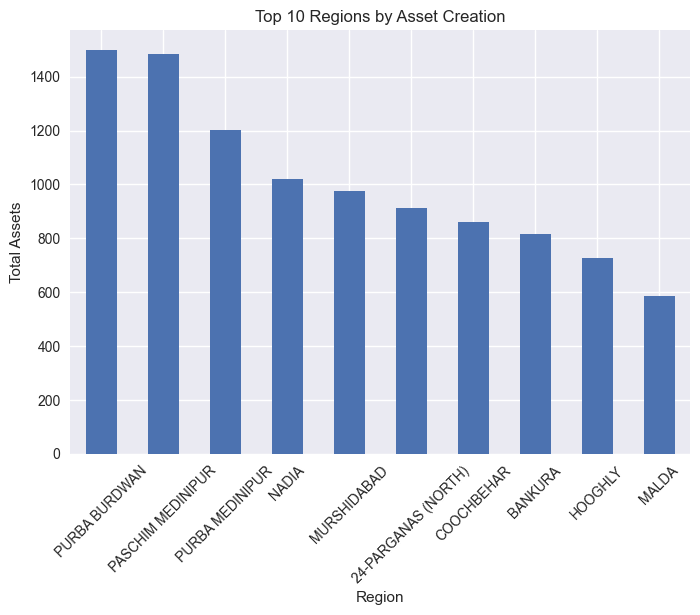

Region
PURBA BURDWAN          1498
PASCHIM MEDINIPUR      1484
PURBA MEDINIPUR        1203
NADIA                  1021
MURSHIDABAD             977
24-PARGANAS (NORTH)     914
COOCHBEHAR              861
BANKURA                 818
HOOGHLY                 726
MALDA                   587
Name: Total, dtype: int64

In [13]:
region_summary = df.groupby("Region")["Total"].sum().sort_values(ascending=False)

plt.figure()
region_summary.head(10).plot(kind="bar")
plt.title("Top 10 Regions by Asset Creation")
plt.xlabel("Region")
plt.ylabel("Total Assets")
plt.xticks(rotation=45)
plt.show()

region_summary.head(10)

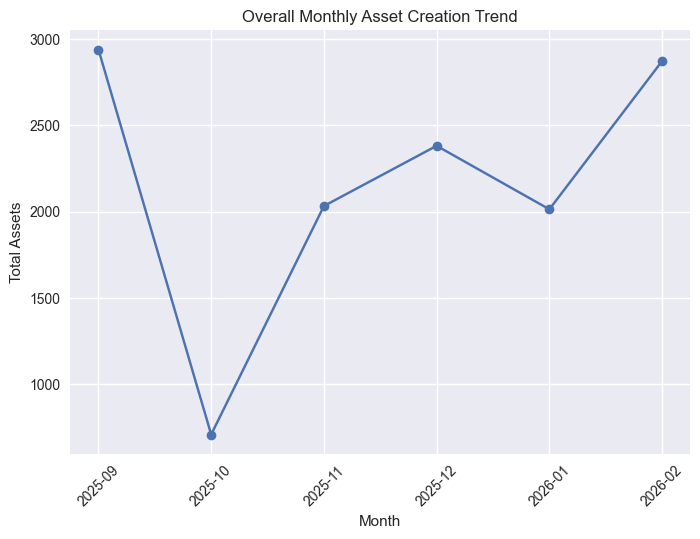

2025-09    2940
2025-10     709
2025-11    2033
2025-12    2382
2026-01    2014
2026-02    2873
dtype: int64

In [14]:
monthly_totals = df[month_cols].sum()

plt.figure()
monthly_totals.plot(marker="o")
plt.title("Overall Monthly Asset Creation Trend")
plt.xlabel("Month")
plt.ylabel("Total Assets")
plt.xticks(rotation=45)
plt.show()

monthly_totals

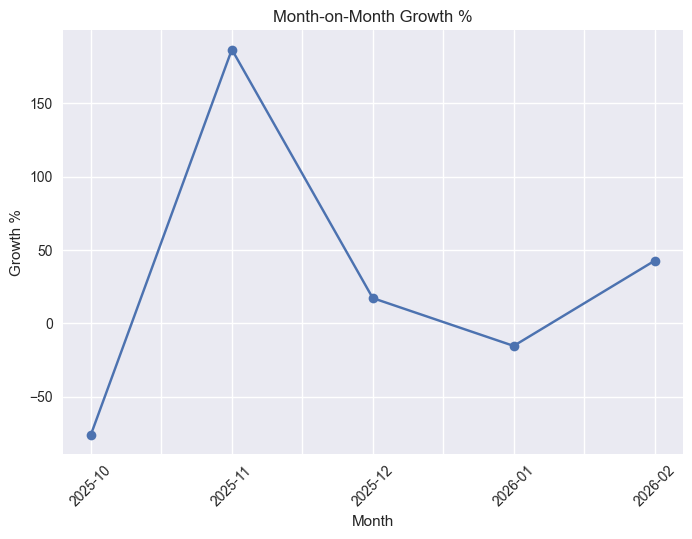

2025-09           NaN
2025-10    -75.884354
2025-11    186.741890
2025-12     17.166749
2026-01    -15.449202
2026-02     42.651440
dtype: float64

In [15]:
mom_growth = monthly_totals.pct_change() * 100

plt.figure()
mom_growth.plot(marker="o")
plt.title("Month-on-Month Growth %")
plt.xlabel("Month")
plt.ylabel("Growth %")
plt.xticks(rotation=45)
plt.show()

mom_growth

In [16]:
top_10 = df.sort_values("Total", ascending=False).head(10)
bottom_10 = df.sort_values("Total").head(10)

print("Top 10 Divisions")
display(top_10[["Zone","Region","Division","Total"]])

print("Bottom 10 Divisions")
display(bottom_10[["Zone","Region","Division","Total"]])

Top 10 Divisions


,Zone,Region,Division,Total
58,Bardhaman,PURBA BURDWAN,KALNA DIVN.,1396
28,Midnapore,PURBA MEDINIPUR,EGRA DIVN.,818
24,Midnapore,PASCHIM MEDINIPUR,BELDA DIVN.,784
23,Midnapore,PASCHIM MEDINIPUR,MIDNAPUR DIVN.,643
53,Siliguri,COOCHBEHAR,DINHATA DIVISION,539
43,Berhampore,NADIA,RANAGHAT DIVISION OFFICE,499
35,Berhampore,MURSHIDABAD,BERHAMPORE DIVN.,459
29,Midnapore,BANKURA,BANKURA DIVN.,400
68,Bardhaman,HOOGHLY,SINGUR-HARIPAL DIVN.,367
15,Kolkata,24-PARGANAS (NORTH),BARASAT DIVN.,297


Bottom 10 Divisions


,Zone,Region,Division,Total
61,Bardhaman,BIRBHUM,SURI DIVN.,0
48,Siliguri,DARJEELING,SILIGURI SUB-URBAN DIVN.,0
57,Bardhaman,PURBA BURDWAN,KATWA DIVN.,0
56,Bardhaman,PURBA BURDWAN,BURDWAN NORTH DIVN.,0
46,Siliguri,DARJEELING,KURSEONG DIVN.,0
63,Bardhaman,BIRBHUM,BOLPUR DIVN.,0
47,Siliguri,DARJEELING,DARJEELING DIVN.,0
66,Bardhaman,HOOGHLY,ARAMBAGH DIVN.,0
69,Bardhaman,HOOGHLY,MOGRA DIVN.,0
70,Bardhaman,PASCHIM BURDWAN,ASANSOL DIVN.,1


In [17]:
zone_percent = (zone_summary / zone_summary.sum()) * 100
zone_percent

Zone
Midnapore     30.854760
Bardhaman     17.604818
Berhampore    15.427380
Kolkata       14.778782
Siliguri      13.265385
Malda          8.068875
Name: Total, dtype: float64

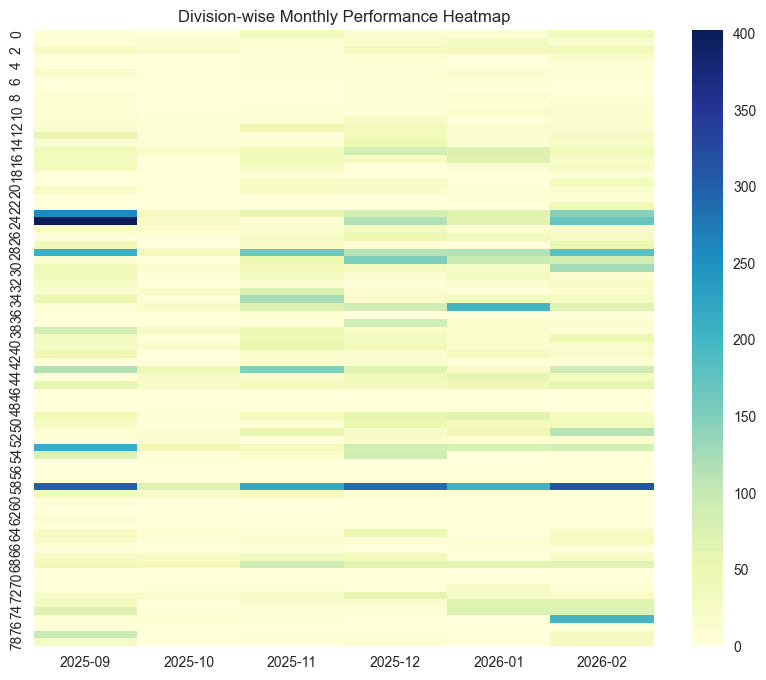

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df[month_cols], cmap="YlGnBu")
plt.title("Division-wise Monthly Performance Heatmap")
plt.show()

In [19]:
df["Volatility"] = df[month_cols].std(axis=1)

most_volatile = df.sort_values("Volatility", ascending=False).head(10)
most_stable = df.sort_values("Volatility").head(10)

print("Most Volatile Divisions")
display(most_volatile[["Division","Volatility"]])

print("Most Stable Divisions")
display(most_stable[["Division","Volatility"]])

Most Volatile Divisions


,Division,Volatility
24,BELDA DIVN.,145.898138
58,KALNA DIVN.,89.783443
23,MIDNAPUR DIVN.,82.093646
75,RAIGANJ DIVISION,79.218053
35,BERHAMPORE DIVN.,68.016910
53,DINHATA DIVISION,64.682043
28,EGRA DIVN.,61.154449
29,BANKURA DIVN.,56.009523
43,RANAGHAT DIVISION OFFICE,45.814481
34,JHARGRAM DIVN.,41.088522


Most Stable Divisions


,Division,Volatility
61,SURI DIVN.,0.000000
48,SILIGURI SUB-URBAN DIVN.,0.000000
57,KATWA DIVN.,0.000000
56,BURDWAN NORTH DIVN.,0.000000
46,KURSEONG DIVN.,0.000000
63,BOLPUR DIVN.,0.000000
47,DARJEELING DIVN.,0.000000
66,ARAMBAGH DIVN.,0.000000
69,MOGRA DIVN.,0.000000
70,ASANSOL DIVN.,0.408248


In [20]:
df["Best Month"] = df[month_cols].idxmax(axis=1)

df[["Division","Best Month"]].head()

,Division,Best Month
0,BEHALA DIVN.,2026-02
1,BARUIPUR DIVN.,2026-01
2,GARIA DIVN.,2026-01
3,JOYNAGAR DIVISION,2026-02
4,DIAMOND HARBOUR DIVN.,2025-09


In [21]:
df["Rank"] = df["Total"].rank(ascending=False, method="dense")

top_ranked = df.sort_values("Rank").head(10)

top_ranked[["Division","Total","Rank"]]

,Division,Total,Rank
58,KALNA DIVN.,1396,1.0
28,EGRA DIVN.,818,2.0
24,BELDA DIVN.,784,3.0
23,MIDNAPUR DIVN.,643,4.0
53,DINHATA DIVISION,539,5.0
43,RANAGHAT DIVISION OFFICE,499,6.0
35,BERHAMPORE DIVN.,459,7.0
29,BANKURA DIVN.,400,8.0
68,SINGUR-HARIPAL DIVN.,367,9.0
15,BARASAT DIVN.,297,10.0


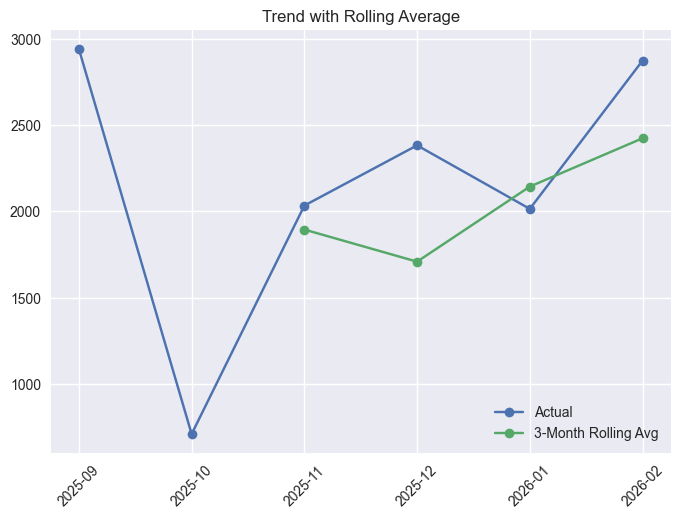

In [22]:
rolling_avg = monthly_totals.rolling(3).mean()

plt.figure()
monthly_totals.plot(label="Actual", marker="o")
rolling_avg.plot(label="3-Month Rolling Avg", marker="o")
plt.legend()
plt.title("Trend with Rolling Average")
plt.xticks(rotation=45)
plt.show()

In [23]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[month_cols])

kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_data)

df[["Division","Cluster"]].head()

,Division,Cluster
0,BEHALA DIVN.,1
1,BARUIPUR DIVN.,1
2,GARIA DIVN.,1
3,JOYNAGAR DIVISION,1
4,DIAMOND HARBOUR DIVN.,1


In [24]:
X = np.arange(len(month_cols)).reshape(-1,1)
y = monthly_totals.values

model = LinearRegression()
model.fit(X, y)

next_month_index = len(month_cols)
forecast = model.predict([[next_month_index]])

print("Forecast for Next Month:", round(forecast[0], 2))

Forecast for Next Month: 2551.4


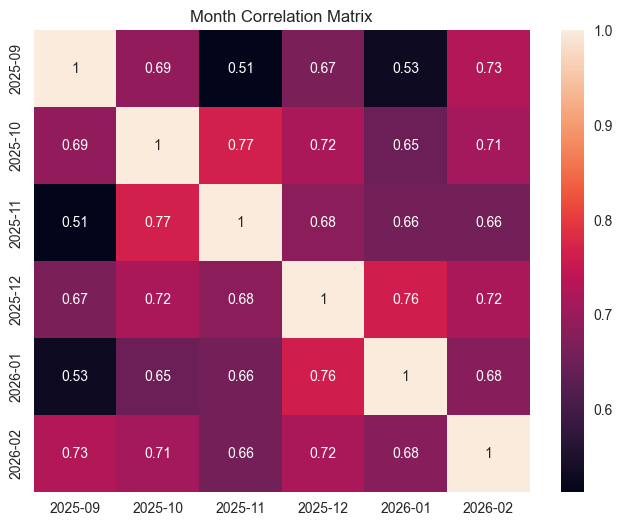

In [25]:
correlation_matrix = df[month_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True)
plt.title("Month Correlation Matrix")
plt.show()

In [26]:
print("========== KPI SUMMARY ==========")
print("Total Assets:", total_assets)
print("Best Month:", monthly_totals.idxmax())
print("Worst Month:", monthly_totals.idxmin())
print("Top Zone:", zone_summary.idxmax())
print("Most Consistent Division:", most_stable.iloc[0]["Division"])
print("Most Volatile Division:", most_volatile.iloc[0]["Division"])
print("Forecast Next Month:", round(forecast[0],2))

========== KPI SUMMARY ==========
Total Assets: 12951
Best Month: 2025-09
Worst Month: 2025-10
Top Zone: Midnapore
Most Consistent Division:  SURI DIVN.               
Most Volatile Division:  BELDA DIVN.              
Forecast Next Month: 2551.4
